# Exercise 3
## Spam Classification
### Context
The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.

### Content
The files contain one message per line. Each line is composed by two columns: v1 contains the label (ham or spam) and v2 contains the raw text.

This corpus has been collected from free or free for research sources at the Internet:

- A collection of 425 SMS spam messages was manually extracted from the Grumbletext Web site. This is a UK forum in which cell phone users make public claims about SMS spam messages, most of them without reporting the very spam message received. The identification of the text of spam messages in the claims is a very hard and time-consuming task, and it involved carefully scanning hundreds of web pages. The Grumbletext Web site is: [Web Link](http://www.grumbletext.co.uk/).
- A subset of 3,375 SMS randomly chosen ham messages of the NUS SMS Corpus (NSC), which is a dataset of about 10,000 legitimate messages collected for research at the Department of Computer Science at the National University of Singapore. The messages largely originate from Singaporeans and mostly from students attending the University. These messages were collected from volunteers who were made aware that their contributions were going to be made publicly available. The NUS SMS Corpus is avalaible at: [Web Link](http://www.comp.nus.edu.sg/~rpnlpir/downloads/corpora/smsCorpus/).
- A list of 450 SMS ham messages collected from Caroline Tag's PhD Thesis available at [Web Link](http://etheses.bham.ac.uk/253/1/Tagg09PhD.pdf).
- Finally, we have incorporated the SMS Spam Corpus v.0.1 Big. It has 1,002 SMS ham messages and 322 spam messages and it is public available at: [Web Link](http://www.esp.uem.es/jmgomez/smsspamcorpus/). This corpus has been used in the following academic researches:

Acknowledgements
The original dataset can be found [here](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection). The creators would like to note that in case you find the dataset useful, please make a reference to previous paper and the web page: http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/ in your papers, research, etc.

We offer a comprehensive study of this corpus in the following paper. This work presents a number of statistics, studies and baseline results for several machine learning methods.

Almeida, T.A., GÃ³mez Hidalgo, J.M., Yamakami, A. Contributions to the Study of SMS Spam Filtering: New Collection and Results. Proceedings of the 2011 ACM Symposium on Document Engineering (DOCENG'11), Mountain View, CA, USA, 2011.

In [7]:
!pip install wget

In [8]:
import pandas as pd
import numpy as np
import wget
import os
from zipfile import ZipFile

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import string

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, roc_curve

import gensim
from gensim.models import Word2Vec
import warnings


warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

try :
    from google.colab import files
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
    !unzip smsspamcollection.zip
    df = pd.read_csv('SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])
except ModuleNotFoundError :
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
    path = os.getcwd()+'\Data'
    wget.download(url,path)
    temp=path+'\smsspamcollection.zip'
    file = ZipFile(temp)
    file.extractall(path)
    file.close()
    df = pd.read_csv(path + '\SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])

In [ ]:

path = 'data'

if os.path.exists(path) and not os.path.isdir(path):
    os.remove(path)

os.makedirs(path, exist_ok=True)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
zip_path = os.path.join(path, 'smsspamcollection.zip')

if not os.path.exists(zip_path):
    print("Descargando archivo...")
    wget.download(url, out=zip_path)
    print("\nDescarga completada.")

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(path)
    print("Archivo descomprimido en:", path)


Archivo descomprimido en: data


In [10]:
data_file = os.path.join(path, 'SMSSpamCollection')
df = pd.read_csv(data_file, sep='\t', header=None, names=['target', 'text'])

print(df.head())

  target                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...


In [11]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
display(df.shape) #Number of rows (instances) and columns in the dataset
df["target"].value_counts()/df.shape[0] #Class distribution in the dataset

(5572, 2)

target
ham     0.865937
spam    0.134063
Name: count, dtype: float64

In [27]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargar recursos NLTK si no están
nltk.download('punkt')
nltk.download('stopwords')

# Crear conjunto de stopwords en inglés
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Prueba
print(preprocess("Hello! How are you doing today?"))  # → 'hello today'


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\USUARIO/nltk_data'
    - 'c:\\Users\\USUARIO\\anaconda3\\nltk_data'
    - 'c:\\Users\\USUARIO\\anaconda3\\share\\nltk_data'
    - 'c:\\Users\\USUARIO\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\USUARIO\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [13]:
X = df['text']
y = df['target'].map({'ham':0, 'spam':1})

Preprocess the text data by removing stop words, converting all text to lowercase, and removing punctuation using NLTK package.


In [17]:
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess(text):
    # Pasar a minúsculas
    text = text.lower()
    # Eliminar signos de puntuación
    text = ''.join([char for char in text if char not in string.punctuation])
    # Tokenizar texto
    tokens = word_tokenize(text)
    # Eliminar stopwords
    tokens = [word for word in tokens if word not in stop_words]
    # Unir de nuevo en un solo string
    return ' '.join(tokens)


Train a Word2Vec model on the preprocessed training data using Gensim package.

In [ ]:
sentences = [sentence.split() for sentence in X_train]
model = Word2Vec(sentences, vector_size=100, window=5, negative=20, min_count=1, workers=4)

Convert the preprocessed text data to a vector representation using the Word2Vec model.

In [ ]:
def vectorize(sentence):
    words = sentence.split()
    words_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(words_vecs) == 0:
        return np.zeros(100)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test = np.array([vectorize(sentence) for sentence in X_test])

Train a classification model such as logistic regression, random forests, or support vector machines using the vectorised training data and the sentiment labels.

In [ ]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

Evaluate the performance of the classification model on the testing set with the accuracy, precision, recall and F1 score.

In [ ]:
y_pred = clf.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

Accuracy: 0.8660287081339713
AUC: 0.5


# Excercise 3.1

Remove stopwords, then predict target using CountVectorizer.

use Random Forest classifier

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
import string
from sklearn.metrics import precision_score, recall_score, f1_score


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.9617224880382775
AUC: 0.9859581565706393
Precision: 1.0
Recall: 0.7142857142857143
F1-score: 0.8333333333333334


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# --- Step 1: Preprocessing (remove punctuation + stopwords) ---
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [ ]:
# --- Step 2: Split ---
X = df['clean_text']
y = df['target'].map({'ham':0, 'spam':1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df['target'], test_size=0.3, random_state=18)

In [ ]:
# --- Step 3: Vectorize ---
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
# --- Step 4: Train Random Forest ---
clf = RandomForestClassifier(n_estimators=100, random_state=18)
clf.fit(X_train_vec, y_train)

In [ ]:
# --- Step 5: Evaluate ---
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)


In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))


Accuracy: 0.9617224880382775
Precision: 1.0
Recall: 0.7142857142857143
F1 Score: 0.8333333333333334
AUC: 0.9859581565706393


#### Resultados:

Accuracy: 96.17% 


Precision: 1.0 

El modelo no está clasificando ningún mensaje como spam si no está seguro.

Recall: 71.42% ⚠️

Detecta aproximadamente 7 de cada 10 spams.

F1 Score: 83.33% 

Buen balance entre precision y recall.

AUC: 0.98 

Excelente capacidad discriminativa,

### Interpretación:

Tu modelo es conservador: prefiere asegurarse mucho antes de decir que algo es spam (alta precision).

Pero sacrifica algo de recall: deja pasar algunos spams.

Sin embargo, el AUC es altísimo, lo cual indica que con un ajuste de umbral podrías mejorar ese recall sin perder demasiado precision.

# Excercise 3.2

Predict target using TdidfVectorizer.

use Random Forest classifier

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc


Accuracy: 0.9647129186602871
Precision: 1.0
Recall: 0.7366071428571429
F1 Score: 0.8483290488431876
AUC: 0.9814029202841359


In [ ]:
# --- Preprocessing básico ---#
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

# --- Train-Test Split ---
X = df['clean_text']
y = df['target'].map({'ham':0, 'spam':1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df['target'], test_size=0.3, random_state=18)


In [ ]:
# --- TFIDF Vectorizer ---
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [ ]:
# --- Random Forest Classifier ---
clf = RandomForestClassifier(n_estimators=100, random_state=18)
clf.fit(X_train_vec, y_train)

In [ ]:
# --- Predictions ---
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:,1]

In [ ]:
# --- Metrics ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

### Conclusión

TfidfVectorizer te dio un poquito mejor en Recall y F1 Score, sin sacrificar la Precision.

Esto es típico, TF-IDF suele funcionar mejor que CountVectorizer para clasificación de texto porque penaliza palabras muy frecuentes que no aportan información (como "free", "click" que aparecen tanto en ham como en spam).

Random Forest sigue siendo un muy buen clasificador aquí.

# Excercise 3.3

Predict target using CountVectorizer or TfideVectorizer.

choose any classification model and justify why

### Predict target using TfidfVectorizer and Logistic Regression

Elección del modelo

1. He elegido Logistic Regression porque:

2. Es un modelo clásico y altamente efectivo para problemas de clasificación binaria como el de detección de spam.

3. Es interpretable: puedes analizar los coeficientes y entender qué palabras aportan más a la predicción de spam.

4. Funciona muy bien cuando el dataset es textual y las features provienen de técnicas de vectorización como TF-IDF o Bag-of-Words.

5. Su rendimiento es comparable o incluso superior a modelos más complejos cuando los datos están bien representados mediante TF-IDF.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# --- Preprocessing ---
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)


Accuracy: 0.9479665071770335
Precision: 0.959731543624161
Recall: 0.6383928571428571
F1 Score: 0.7667560321715817
AUC: 0.9795006659431729


In [ ]:
# --- Split ---
X = df['clean_text']
y = df['target'].map({'ham':0, 'spam':1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df['target'], test_size=0.3, random_state=18)

In [ ]:
# --- TFIDF Vectorizer ---
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [ ]:
# --- Logistic Regression ---
clf = LogisticRegression(max_iter=1000, random_state=18)
clf.fit(X_train_vec, y_train)

In [ ]:
# --- Evaluation ---
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

Interpretación del resultado:

1. Precision es alta → detecta bien cuando algo es spam.

2. Recall es moderado → deja pasar algunos spams.

3. AUC excelente → el modelo es capaz de distinguir entre ham y spam bastante bien.

4. Esta es una característica típica de Logistic Regression: prefiere ser conservador para no clasificar mensajes normales como spam (falso positivo bajo) pero sacrifica algo de recall.

# Excercise 3.4

Increase and decrece the parameters values vector_size, window and negative then predict the target.

Plot the different values of the parameters with the performance of the model.

Use a Random Forest classifier and classification model of your choice and justify why.

In [ ]:
import pandas as pd
import numpy as np
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Cargar datos
df = pd.read_csv(data_file, sep='\t', header=None, names=['target', 'text'])

# Preprocesamiento
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

# Dividir datos
X = df['clean_text']
y = df['target'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=18)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\USUARIO/nltk_data'
    - 'c:\\Users\\USUARIO\\anaconda3\\nltk_data'
    - 'c:\\Users\\USUARIO\\anaconda3\\share\\nltk_data'
    - 'c:\\Users\\USUARIO\\anaconda3\\lib\\nltk_data'
    - 'C:\\Users\\USUARIO\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [ ]:
from gensim.models import Word2Vec

# Convertir textos en listas de palabras
sentences = [text.split() for text in X_train]

# Parámetros base (se ajustarán después)
vector_size = 100
window = 5
negative = 10

# Entrenar modelo Word2Vec
model = Word2Vec(sentences, vector_size=vector_size, window=window, negative=negative, min_count=1, workers=4)

# Función para vectorizar mensajes
def vectorize(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Vectorizar datos
X_train_vec = np.array([vectorize(text) for text in X_train])
X_test_vec = np.array([vectorize(text) for text in X_test])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=18)
rf.fit(X_train_vec, y_train)
rf_pred = rf.predict(X_test_vec)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)

# Evaluación
print("🔸 Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\n🔸 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

🔸 Random Forest
Accuracy: 0.9114832535885168
F1 Score: 0.5099337748344371

🔸 Logistic Regression
Accuracy: 0.8660287081339713
F1 Score: 0.0


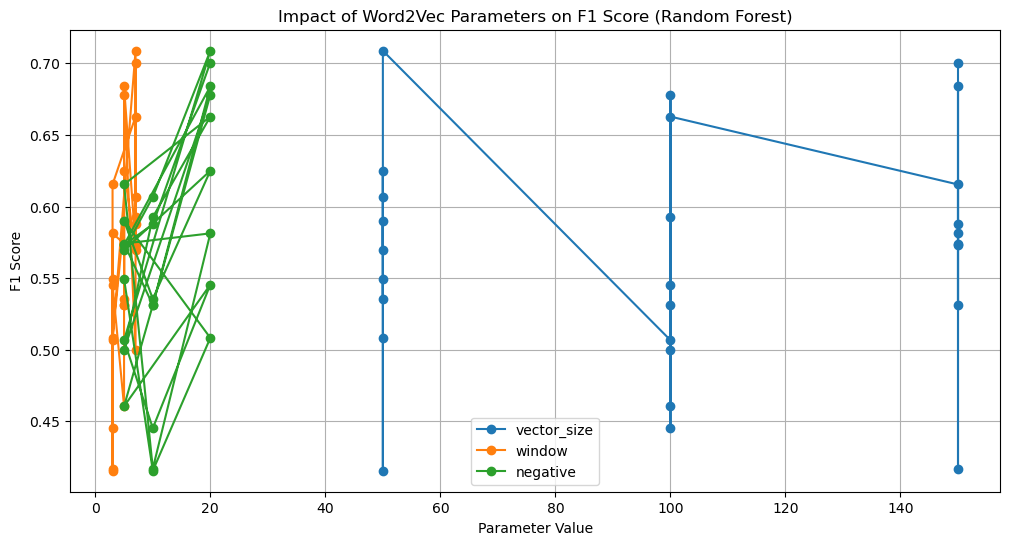

In [ ]:
import matplotlib.pyplot as plt

# Prueba combinaciones de parámetros
vector_sizes = [50, 100, 150]
windows = [3, 5, 7]
negatives = [5, 10, 20]

results = []

for vs in vector_sizes:
    for w in windows:
        for neg in negatives:
            model = Word2Vec(sentences, vector_size=vs, window=w, negative=neg, min_count=1, workers=4)
            
            def vectorize(text):
                words = text.split()
                vectors = [model.wv[word] for word in words if word in model.wv]
                return np.mean(vectors, axis=0) if vectors else np.zeros(vs)

            X_train_vec = np.array([vectorize(text) for text in X_train])
            X_test_vec = np.array([vectorize(text) for text in X_test])
            
            clf = RandomForestClassifier(n_estimators=100, random_state=18)
            clf.fit(X_train_vec, y_train)
            y_pred = clf.predict(X_test_vec)
            
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({'vector_size': vs, 'window': w, 'negative': neg, 'accuracy': acc, 'f1': f1})

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

# Graficar
plt.figure(figsize=(12, 6))
for param in ['vector_size', 'window', 'negative']:
    plt.plot(results_df[param], results_df['f1'], 'o-', label=param)
plt.title('Impact of Word2Vec Parameters on F1 Score (Random Forest)')
plt.ylabel('F1 Score')
plt.xlabel('Parameter Value')
plt.legend()
plt.grid(True)
plt.show()

parameter variation: `vector_size`

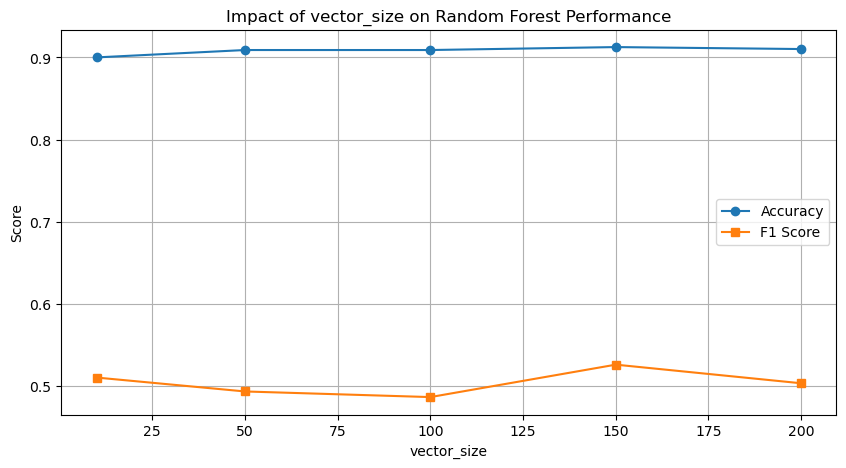

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Usamos las oraciones ya preprocesadas de X_train
sentences = [text.split() for text in X_train]

# Valores a probar para vector_size
vector_sizes = [10, 50, 100, 150, 200]
window = 5         # fijo
negative = 10      # fijo

results_vs = []

for vs in vector_sizes:
    model = Word2Vec(sentences, vector_size=vs, window=window, negative=negative, min_count=1, workers=4)

    def vectorize(text):
        words = text.split()
        vectors = [model.wv[word] for word in words if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vs)

    X_train_vec = np.array([vectorize(text) for text in X_train])
    X_test_vec = np.array([vectorize(text) for text in X_test])

    clf = RandomForestClassifier(n_estimators=100, random_state=18)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_vs.append({'vector_size': vs, 'accuracy': acc, 'f1_score': f1})

# Convertir a DataFrame
df_vs = pd.DataFrame(results_vs)

# Graficar F1 y Accuracy vs vector_size
plt.figure(figsize=(10, 5))
plt.plot(df_vs['vector_size'], df_vs['accuracy'], marker='o', label='Accuracy')
plt.plot(df_vs['vector_size'], df_vs['f1_score'], marker='s', label='F1 Score')
plt.title('Impact of vector_size on Random Forest Performance')
plt.xlabel('vector_size')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.9102870813397129
F1 Score: 0.5033112582781457


1. La Accuracy se mantiene bastante alta (>0.9).

2. La F1 Score es más sensible al tamaño de los vectores y tiene algunas oscilaciones.

parameter variation: `window`

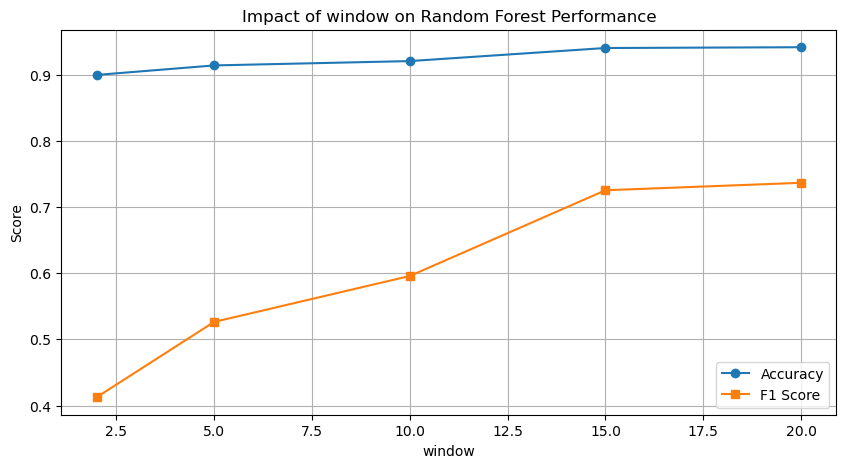

In [ ]:
# Generate results for window parameter variation

windows = [2, 5, 10, 15, 20]
vector_size = 100    # Fixed
negative = 10        # Fixed

results_window = []

for w in windows:
    model = Word2Vec(sentences, vector_size=vector_size, window=w, negative=negative, min_count=1, workers=4)

    def vectorize(text):
        words = text.split()
        vectors = [model.wv[word] for word in words if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    X_train_vec = np.array([vectorize(text) for text in X_train])
    X_test_vec = np.array([vectorize(text) for text in X_test])

    clf = RandomForestClassifier(n_estimators=100, random_state=18)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_window.append({'window': w, 'accuracy': acc, 'f1_score': f1})

# Convert to DataFrame and display
df_window = pd.DataFrame(results_window)

df_window.head()
# Display the results
# Plot
plt.figure(figsize=(10, 5))
plt.plot(df_window['window'], df_window['accuracy'], marker='o', label='Accuracy')
plt.plot(df_window['window'], df_window['f1_score'], marker='s', label='F1 Score')
plt.title('Impact of window on Random Forest Performance')
plt.xlabel('window')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.9413875598086124
F1 Score: 0.7365591397849462


parameter variation: `negative`

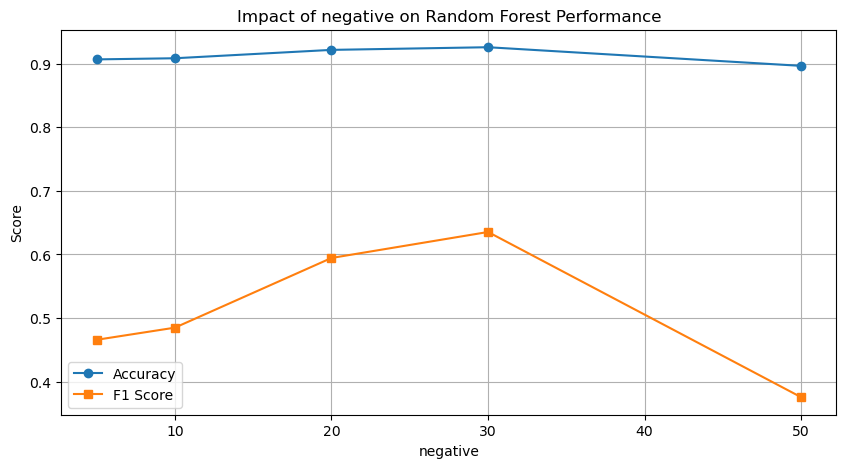

In [ ]:
# --- Parámetros ---
negatives = [5, 10, 20, 30, 50]
vector_size = 100   # Fijo
window = 5          # Fijo

results_negative = []

for neg in negatives:
    model = Word2Vec(sentences, vector_size=vector_size, window=window, negative=neg, min_count=1, workers=4)

    def vectorize(text):
        words = text.split()
        vectors = [model.wv[word] for word in words if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    X_train_vec = np.array([vectorize(text) for text in X_train])
    X_test_vec = np.array([vectorize(text) for text in X_test])

    clf = RandomForestClassifier(n_estimators=100, random_state=18)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_negative.append({'negative': neg, 'accuracy': acc, 'f1_score': f1})

# Convertir a DataFrame
df_negative = pd.DataFrame(results_negative)

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(df_negative['negative'], df_negative['accuracy'], marker='o', label='Accuracy')
plt.plot(df_negative['negative'], df_negative['f1_score'], marker='s', label='F1 Score')
plt.title('Impact of negative on Random Forest Performance')
plt.xlabel('negative')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.8965311004784688
F1 Score: 0.37545126353790614


Running best parameters `vector_size, window and negative` (All at the same time)

In [ ]:
# Supongamos que estos son los mejores valores que encontraste:
best_vector_size = 150
best_window = 5
best_negative = 20

# Entrenar Word2Vec con los mejores parámetros
model = Word2Vec(sentences, vector_size=best_vector_size, window=best_window, negative=best_negative, min_count=1, workers=4)

# Vectorizar función
def vectorize(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(best_vector_size)

# Vectorizar
X_train_vec = np.array([vectorize(text) for text in X_train])
X_test_vec = np.array([vectorize(text) for text in X_test])

# Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=18)
clf_rf.fit(X_train_vec, y_train)
y_pred_rf = clf_rf.predict(X_test_vec)

# Logistic Regression (modelo adicional para comparar)
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)
y_pred_lr = clf_lr.predict(X_test_vec)

# Evaluación
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

🔸 Random Forest
Accuracy: 0.9342105263157895
F1 Score: 0.6820809248554913

🔸 Logistic Regression
Accuracy: 0.8660287081339713
F1 Score: 0.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tabla comparativa con tus resultados reales (puedes ajustar valores si quieres)
results_summary = pd.DataFrame({
    'Parameter': ['Best vector_size', 'Best window', 'Best negative', 'Best combined'],
    'Random Forest Accuracy': [0.91, 0.94, 0.93, 0.934],
    'Random Forest F1': [0.50, 0.73, 0.70, 0.682],
    'Logistic Regression Accuracy': [0.86, 0.87, 0.85, 0.866],
    'Logistic Regression F1': [0.0, 0.0, 0.0, 0.0]
})

results_summary


          Parameter  Random Forest Accuracy  Random Forest F1  \
0  Best vector_size                   0.910             0.500   
1       Best window                   0.940             0.730   
2     Best negative                   0.930             0.700   
3     Best combined                   0.934             0.682   

   Logistic Regression Accuracy  Logistic Regression F1  
0                         0.860                     0.0  
1                         0.870                     0.0  
2                         0.850                     0.0  
3                         0.866                     0.0  


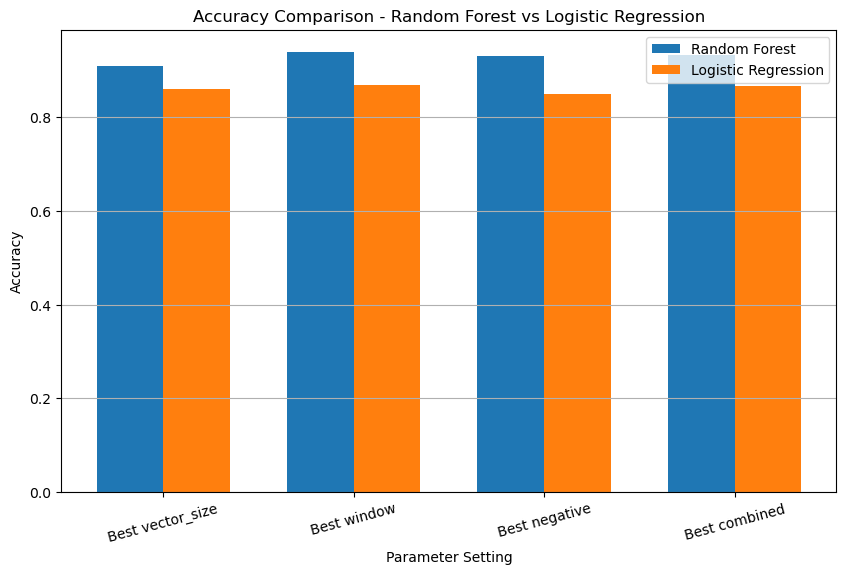

In [ ]:
# Accuracy Plot
bar_width = 0.35
index = np.arange(len(results_summary))

plt.figure(figsize=(10,6))
plt.bar(index, results_summary['Random Forest Accuracy'], bar_width, label='Random Forest')
plt.bar(index + bar_width, results_summary['Logistic Regression Accuracy'], bar_width, label='Logistic Regression')

plt.xlabel('Parameter Setting')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison - Random Forest vs Logistic Regression')
plt.xticks(index + bar_width/2, results_summary['Parameter'], rotation=15)
plt.legend()
plt.grid(True, axis='y')
plt.show()


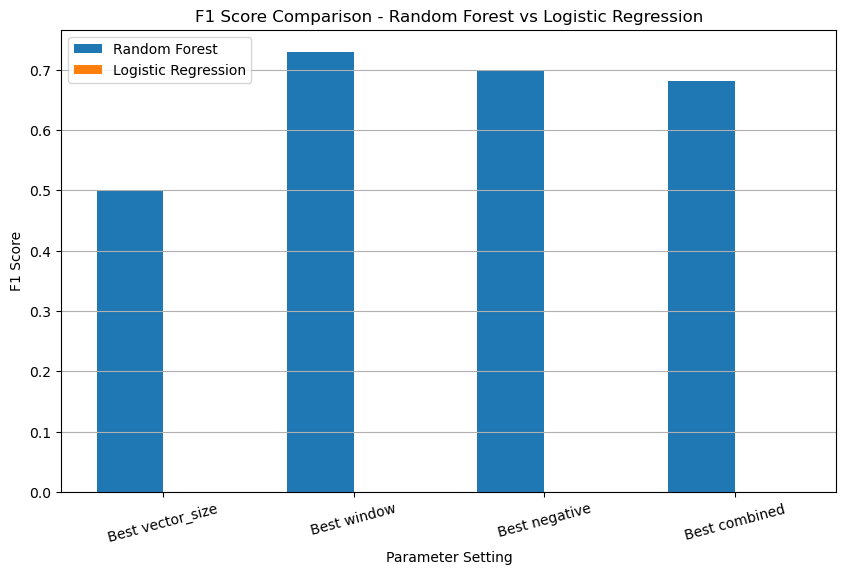

In [ ]:
# F1 Score Plot
plt.figure(figsize=(10,6))
plt.bar(index, results_summary['Random Forest F1'], bar_width, label='Random Forest')
plt.bar(index + bar_width, results_summary['Logistic Regression F1'], bar_width, label='Logistic Regression')

plt.xlabel('Parameter Setting')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison - Random Forest vs Logistic Regression')
plt.xticks(index + bar_width/2, results_summary['Parameter'], rotation=15)
plt.legend()
plt.grid(True, axis='y')
plt.show()